In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Análisis Exploratorio

In [ ]:
df = pd.read_csv('telco_churn.csv')

In [ ]:
df.head()

,churn,tenure_months,monthly_charges,total_services,support_calls_last90d,late_payments_12m,downtime_hrs_6m,contract,internet,payment_method,support_tier,promo_status
0,0,5.2,91.13,3,1,1,3.75,month-to-month,fiber,bank_transfer,basic,never
1,0,22.0,19.04,2,3,2,3.22,one-year,fiber,credit_card,basic,never
2,0,25.8,77.94,2,1,0,2.06,month-to-month,fiber,electronic_check,basic,never
3,0,6.8,91.52,1,4,1,0.60,one-year,fiber,bank_transfer,plus,never
4,0,18.7,54.31,1,2,1,0.00,two-year,none,bank_transfer,plus,past


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   churn                  12000 non-null  int64  
 1   tenure_months          12000 non-null  float64
 2   monthly_charges        12000 non-null  float64
 3   total_services         12000 non-null  int64  
 4   support_calls_last90d  12000 non-null  int64  
 5   late_payments_12m      12000 non-null  int64  
 6   downtime_hrs_6m        12000 non-null  float64
 7   contract               12000 non-null  object 
 8   internet               12000 non-null  object 
 9   payment_method         12000 non-null  object 
 10  support_tier           12000 non-null  object 
 11  promo_status           12000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.1+ MB


Relación entre la salida y las variables continuas

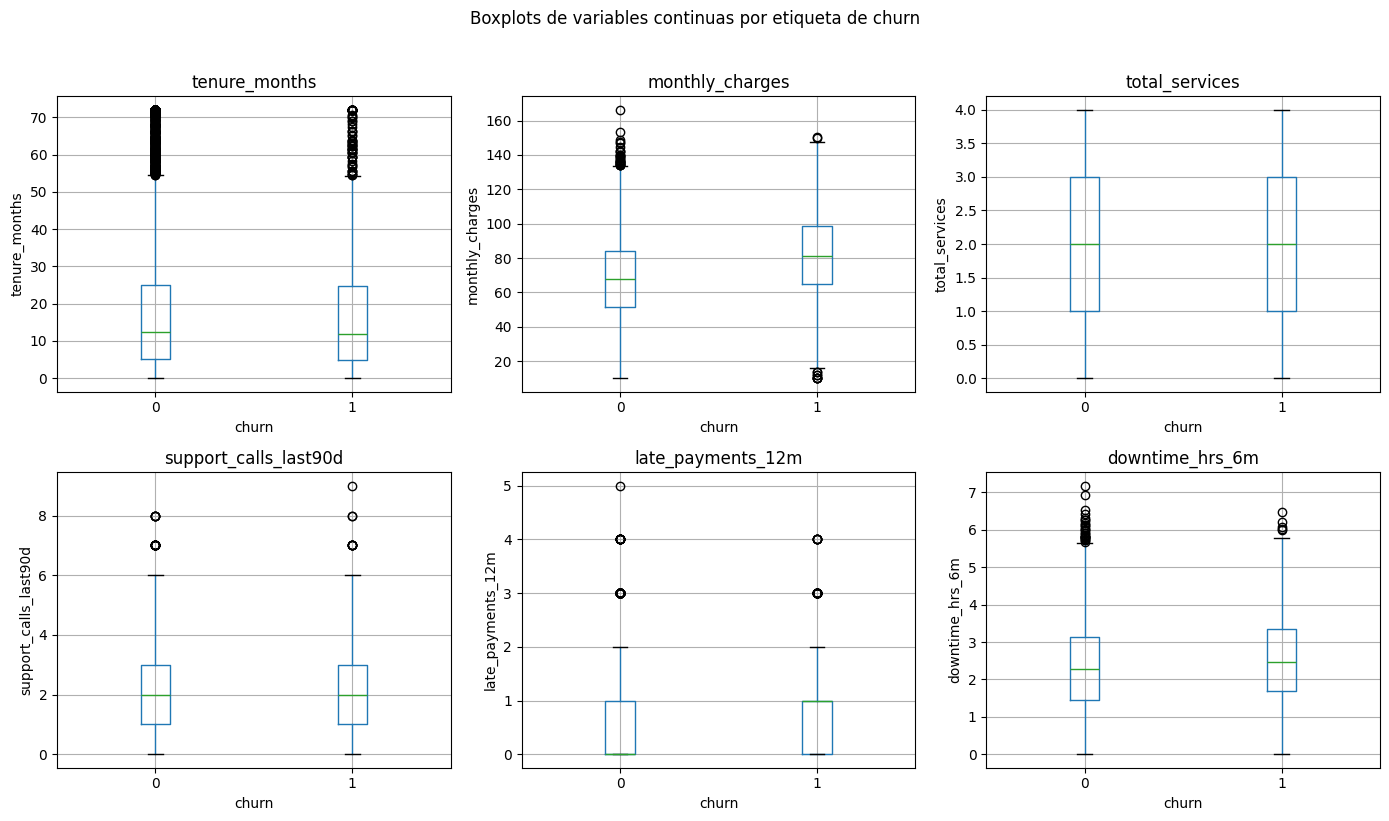

In [ ]:
import matplotlib.pyplot as plt

cont_vars = ["tenure_months","monthly_charges","total_services",
             "support_calls_last90d","late_payments_12m","downtime_hrs_6m"]

ncols = 3
nrows = int(np.ceil(len(cont_vars)/ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 8))

for ax, col in zip(axes.flatten(), cont_vars):
    df.boxplot(column=col, by="churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("churn")
    ax.set_ylabel(col)

plt.suptitle("Boxplots de variables continuas por etiqueta de churn", y=1.02)
plt.tight_layout()
plt.show()


Relación entre la salida y las variables categóricas

In [ ]:
# Calcular proporciones de cada categoría dentro de cada etiqueta de churn
cat_cols = ["contract","internet","payment_method","support_tier","promo_status"]

proportions = {}
for col in cat_cols:
    tab = pd.crosstab(df[col], df["churn"], normalize="columns") * 100
    proportions[col] = tab

# Convertir a un solo dataframe concatenado
prop_df = pd.concat(proportions, axis=0)
prop_df = prop_df.rename_axis(index=["variable","categoria"])

display(prop_df.round(2))

churn                                0      1
variable       categoria                     
contract       month-to-month    58.62  82.15
               one-year          24.38  13.60
               two-year          17.00   4.25
internet       dsl               36.85  24.29
               fiber             47.66  66.42
               none              15.48   9.29
payment_method bank_transfer     25.87  21.66
               credit_card       25.09  21.82
               electronic_check  49.05  56.52
support_tier   basic             57.58  72.41
               plus              31.48  20.15
               premium           10.94   7.44
promo_status   current           22.20  11.75
               never             40.54  37.88
               past              37.27  50.36

Distribución de la variable de salida

In [ ]:
np.mean(df['churn'])

np.float64(0.14891666666666667)